In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df.shape)
print(df.columns.tolist())
df.head()


(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']


,function,name,d,q,GRH,t,|M|,log_abs_S0_norm,log_abs_S0,abs_S0,...,abs_S4,log_abs_S5_norm,log_abs_S5,abs_S5,log_abs_S6_norm,log_abs_S6,abs_S6,log_abs_S7_norm,log_abs_S7,abs_S7
0,F1,zeta,1,1,True,77403.7,14.060888,0.0,0.0,1.0,...,2.603624,0.085554,0.207123,1.230133,-0.523985,-1.268552,0.281238,-2.281314,-5.522997,0.003994
1,F1,zeta,1,1,True,74956.0,13.948294,0.0,0.0,1.0,...,2.637044,-0.029346,-0.070961,0.931498,-0.695810,-1.682548,0.185900,-2.191351,-5.298934,0.004997
2,F1,zeta,1,1,True,94526.8,13.610746,0.0,0.0,1.0,...,3.502890,0.089788,0.218954,1.244774,-0.701922,-1.711686,0.180561,-2.438321,-5.946016,0.002616
3,F1,zeta,1,1,True,97255.1,13.262598,0.0,0.0,1.0,...,4.073511,0.288978,0.705409,2.024675,-0.396795,-0.968595,0.379616,-2.244808,-5.479689,0.004171
4,F1,zeta,1,1,True,63751.9,13.129894,0.0,0.0,1.0,...,2.653296,-0.313243,-0.752905,0.470996,-1.324152,-3.182710,0.041473,-2.916408,-7.009831,0.000903


In [2]:
print(df['function'].value_counts())
print()
print(df.groupby('function')['GRH'].first())


function
F1 200
F2 200
F4 200
F5p 200
F5m 200
F6 200
F7 200
F9 200
F10 200
F11 200
F12 200
Name: count, dtype: int64

function
F1 True
F10 True
F11 True
F12 False
F2 True
F4 False
F5m False
F5p False
F6 True
F7 True
F9 True
Name: GRH, dtype: bool


In [3]:
# The S_k values in the CSV are |S_k| (magnitudes), not complex.
# M_jk = E[Re(S_j * conj(S_k))] requires complex S_j values, but we only have |S_k|.
# However, given the data we have, we can compute a real symmetric proxy:
# E[|S_j| * |S_k|] but that's not the actual cross-term matrix.
# Or, since S_0 is normalized to 1 (real), and abs_Sk is the magnitude...
# Let me check what we actually have.
print(df[['abs_S0','abs_S1','abs_S2','abs_S3']].head())
print()
# All abs_S0 are 1, since they're normalized by main sum magnitude
print("Unique abs_S0:", df['abs_S0'].unique())


 abs_S0 abs_S1 abs_S2 abs_S3
0 1.0 5.315307 10.054481 8.283359
1 1.0 5.080392 10.091729 7.734909
2 1.0 5.148658 9.403108 7.253702
3 1.0 4.567912 8.673870 6.149752
4 1.0 4.883110 9.363674 7.789347

Unique abs_S0: [1. 2.07596189]


In [4]:
# We only have magnitudes, not the complex values. The proper M_jk = E[Re(S_j * conj(S_k))] 
# can't be exactly computed without complex values. However, we can compute the proxy
# M_jk = E[|S_j| * |S_k|] which captures the cross-correlation structure of magnitudes.
# This is a positive semi-definite outer-product-style matrix.
# 
# Note: r21-r24 reportedly used the actual ω-stratified matrix. But here we work with what's available.
# Let me document this limitation clearly. We'll proceed with M_jk = E[|S_j| |S_k|] as the
# best available proxy from this CSV, since the complex S_k values are not stored here.

# Actually, looking again - the diagonal would be E[|S_k|^2]. Let's compute it.
classes = sorted(df['function'].unique())
print(classes)
M_dict = {}
for cls in classes:
 sub = df[df['function']==cls]
 abs_S = sub[[f'abs_S{k}' for k in range(8)]].values # (200, 8)
 # M_jk = E[|S_j| * |S_k|]
 M = (abs_S.T @ abs_S) / abs_S.shape[0]
 M_dict[cls] = M

print("M_F1 diag:", np.diag(M_dict['F1']))
print("M_F12 diag:", np.diag(M_dict['F12']))


['F1', 'F10', 'F11', 'F12', 'F2', 'F4', 'F5m', 'F5p', 'F6', 'F7', 'F9']
M_F1 diag: [1.00000000e+00 1.88657153e+01 5.06440877e+01 3.08709801e+01
 1.03541624e+01 2.25032654e+00 5.86551659e-02 1.53721168e-05]
M_F12 diag: [4.30961779e+00 7.99958990e+01 2.10423116e+02 1.39752762e+02
 5.89031920e+01 5.26532242e+00 2.03199959e-02 0.00000000e+00]


In [5]:
# Note S_7 column is essentially zero for some classes (feature leak per memo).
# Compute eigenvalue spectra & spectral features
spectral = {}
for cls, M in M_dict.items():
 # M is symmetric PSD by construction
 eigvals = np.linalg.eigvalsh(M)
 eigvals = np.clip(eigvals, 0, None) # numerical safety
 eigvals_sorted = np.sort(eigvals)[::-1]
 s = eigvals_sorted.sum()
 if s == 0:
 pc1 = 0.0; H = 0.0
 else:
 p = eigvals_sorted / s
 pc1 = p[0]
 # entropy excluding zero p
 nz = p[p>0]
 H = float(-np.sum(nz * np.log(nz)))
 spectral[cls] = {'pc1_variance_fraction': pc1, 'eigenvalue_entropy': H,
 'eigvals': eigvals_sorted}

import pandas as pd
spec_df = pd.DataFrame({cls:{'pc1':spectral[cls]['pc1_variance_fraction'],
 'H':spectral[cls]['eigenvalue_entropy'],
 'GRH': df[df['function']==cls]['GRH'].iloc[0]} 
 for cls in classes}).T
print(spec_df)


 pc1 H GRH
F1 0.983991 0.097304 True
F10 0.989781 0.063979 True
F11 0.98756 0.075891 True
F12 0.972986 0.150934 False
F2 0.986173 0.084759 True
F4 0.971296 0.163591 False
F5m 0.971102 0.164476 False
F5p 0.971046 0.164681 False
F6 0.968822 0.16103 True
F7 0.972198 0.147787 True
F9 0.98553 0.085353 True


In [6]:
# Interesting - GRH-false (F4, F5m, F5p, F12) tend to have lower pc1 and higher entropy, 
# but F6, F7 are also high entropy though GRH-true. F1, F9, F10, F11, F2 are concentrated.
# Add spectral features to dataframe
df['pc1_variance_fraction'] = df['function'].map(lambda c: spectral[c]['pc1_variance_fraction'])
df['eigenvalue_entropy'] = df['function'].map(lambda c: spectral[c]['eigenvalue_entropy'])

# Save augmented file
df.to_csv('peaks_features_F1_F12_normalized_full_with_spectral.csv', index=False)
print(df.shape)
print(df[['function','GRH','pc1_variance_fraction','eigenvalue_entropy']].drop_duplicates())


(2200, 33)
 function GRH pc1_variance_fraction eigenvalue_entropy
0 F1 True 0.983991 0.097304
200 F2 True 0.986173 0.084759
400 F4 False 0.971296 0.163591
600 F5p False 0.971046 0.164681
800 F5m False 0.971102 0.164476
1000 F6 True 0.968822 0.161030
1200 F7 True 0.972198 0.147787
1400 F9 True 0.985530 0.085353
1600 F10 True 0.989781 0.063979
1800 F11 True 0.987560 0.075891
2000 F12 False 0.972986 0.150934


In [7]:
# Strict protocol: train F1, F4, F9 ; test F2, F6, F7, F10, F11, F12
# Per memo: exclude S_7 features (feature leak at N=10^6).
# Predict GRH (binary).
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

train_classes = ['F1','F4','F9']
test_classes = ['F2','F6','F7','F10','F11','F12']

train = df[df['function'].isin(train_classes)].copy()
test = df[df['function'].isin(test_classes)].copy()

logS_cols_full = [f'log_abs_S{k}_norm' for k in range(8)]
logS_cols = [f'log_abs_S{k}_norm' for k in range(7)] # exclude S7
spec_cols = ['pc1_variance_fraction','eigenvalue_entropy']

print("Train:", train.shape, " Test:", test.shape)
print("Train GRH counts:", train['GRH'].value_counts().to_dict())
print("Test GRH counts:", test['GRH'].value_counts().to_dict())


Train: (600, 33) Test: (1200, 33)
Train GRH counts: {True: 400, False: 200}
Test GRH counts: {True: 1000, False: 200}


In [8]:
# Note: spectral features are class-level constants, so within a class all rows share the same value.
# This means for the held-out classes, spectral features are constants per class.
# The model essentially memorizes 3 (class, GRH) pairs in training: 
# F1 -> True, F4 -> False, F9 -> True
# Then at test it has new spectral values for F2, F6, F7, F10, F11, F12.
# This is an extremely degenerate situation. Let's still run it carefully.

def fit_predict(X_tr, y_tr, X_te, y_te, model='logreg'):
 sc = StandardScaler().fit(X_tr)
 Xtr = sc.transform(X_tr); Xte = sc.transform(X_te)
 if model == 'logreg':
 m = LogisticRegression(max_iter=2000, C=1.0)
 else:
 m = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
 m.fit(Xtr, y_tr)
 if hasattr(m,'predict_proba'):
 p = m.predict_proba(Xte)[:,1]
 else:
 p = m.decision_function(Xte)
 auc = roc_auc_score(y_te, p)
 return auc, p, m

# Bootstrap CI (cluster bootstrap on test classes) since rows within a class are not independent
def bootstrap_ci_class(test_df, probs, y, n_boot=2000, seed=0):
 rng = np.random.default_rng(seed)
 classes = test_df['function'].unique()
 aucs = []
 for _ in range(n_boot):
 sampled = rng.choice(classes, size=len(classes), replace=True)
 idx = np.concatenate([test_df.index[test_df['function']==c].to_numpy() for c in sampled])
 # map to positional index in test
 pos = np.array([test_df.index.get_loc(i) for i in idx])
 yb = y[pos]; pb = probs[pos]
 if len(np.unique(yb)) < 2:
 continue
 try:
 aucs.append(roc_auc_score(yb, pb))
 except Exception:
 continue
 return np.percentile(aucs,[2.5,97.5]), np.mean(aucs), np.std(aucs)

results = {}
for name, cols in [('logS_only', logS_cols), ('spectral_only', spec_cols), ('combined', logS_cols+spec_cols)]:
 Xtr = train[cols].values; ytr = (~train['GRH']).astype(int).values # predict GRH-false=1
 Xte = test[cols].values; yte = (~test['GRH']).astype(int).values
 auc, probs, m = fit_predict(Xtr, ytr, Xte, yte, model='logreg')
 ci, mb, sb = bootstrap_ci_class(test.reset_index(drop=True), probs, yte)
 results[name] = {'auc':auc, 'ci':ci, 'boot_mean':mb}
 print(f"{name:15s} AUC={auc:.4f} 95%CI(class-boot)=[{ci[0]:.4f}, {ci[1]:.4f}] features={cols}")


logS_only AUC=0.0806 95%CI(class-boot)=[0.0180, 0.1773] features=['log_abs_S0_norm', 'log_abs_S1_norm', 'log_abs_S2_norm', 'log_abs_S3_norm', 'log_abs_S4_norm', 'log_abs_S5_norm', 'log_abs_S6_norm']


spectral_only AUC=0.6000 95%CI(class-boot)=[0.2000, 1.0000] features=['pc1_variance_fraction', 'eigenvalue_entropy']


combined AUC=0.6014 95%CI(class-boot)=[0.2026, 1.0000] features=['log_abs_S0_norm', 'log_abs_S1_norm', 'log_abs_S2_norm', 'log_abs_S3_norm', 'log_abs_S4_norm', 'log_abs_S5_norm', 'log_abs_S6_norm', 'pc1_variance_fraction', 'eigenvalue_entropy']


In [9]:
# logS-only AUC=0.08 means the model is strongly anti-correctly oriented on held out classes.
# That's consistent with prior r25 finding: log|S_k| features fail under strict class hold-out.
# spectral-only AUC=0.60 with extremely wide CI [0.20, 1.0] - because spectral features are 
# class-level constants and we only have 6 test classes.

# Let's also try a Random Forest as a sanity check and compute per-class predictions
for name, cols in [('logS_only', logS_cols), ('spectral_only', spec_cols), ('combined', logS_cols+spec_cols)]:
 Xtr = train[cols].values; ytr = (~train['GRH']).astype(int).values
 Xte = test[cols].values; yte = (~test['GRH']).astype(int).values
 auc, probs, m = fit_predict(Xtr, ytr, Xte, yte, model='rf')
 print(f"RF {name:15s} AUC={auc:.4f}")


RF logS_only AUC=0.1755


RF spectral_only AUC=0.8000


RF combined AUC=0.7257


In [10]:
# Per-class mean predicted prob for spectral_only logreg
cols = spec_cols
Xtr = train[cols].values; ytr = (~train['GRH']).astype(int).values
Xte = test[cols].values; yte = (~test['GRH']).astype(int).values
auc, probs, m = fit_predict(Xtr, ytr, Xte, yte, model='logreg')
test_with_p = test[['function','GRH']].copy()
test_with_p['p_GRHfalse'] = probs
print(test_with_p.groupby(['function','GRH'])['p_GRHfalse'].mean())
print()
# Inspect the model
print("logreg coef (spectral_only):", m.coef_, "intercept:", m.intercept_)


function GRH 
F10 True 0.000040
F11 True 0.000244
F12 False 0.967251
F2 True 0.000846
F6 True 0.997204
F7 True 0.970027
Name: p_GRHfalse, dtype: float64

logreg coef (spectral_only): [[-2.65392065 2.58614874]] intercept: [-2.31545499]


In [11]:
# Spectral features correctly identify F12 as GRH-false, but also flag F6 and F7 (both GRH-true) as GRH-false.
# Per-class results for spectral: TP F12, but FP F6, F7. TN F2, F10, F11.
# Sensitivity = 1/1=1, Specificity = 3/5=0.6. AUC=0.6 is right.

# Let's also do the proper 95% CI by class-stratified bootstrap *of training fit* by retraining... 
# but training set is fixed (3 classes). Real uncertainty: only 6 test classes. 
# Compute Wilson-style or just keep the class-bootstrap CI.

# Save final results
import json
final = {
 'logS_only': {'AUC': 0.0806, 'CI95': [0.0180, 0.1773]},
 'spectral_only': {'AUC': 0.6000, 'CI95': [0.2000, 1.0000]},
 'combined': {'AUC': 0.6014, 'CI95': [0.2026, 1.0000]},
 'note': 'CI from class-stratified bootstrap (6 held-out classes); model = logistic regression. RF results: logS=0.176, spectral=0.800, combined=0.726.'
}
with open('strict_protocol_spectral_results.json','w') as f:
 json.dump(final, f, indent=2)
print(json.dumps(final, indent=2))


{
 "logS_only": {
 "AUC": 0.0806,
 "CI95": [
 0.018,
 0.1773
 ]
 },
 "spectral_only": {
 "AUC": 0.6,
 "CI95": [
 0.2,
 1.0
 ]
 },
 "combined": {
 "AUC": 0.6014,
 "CI95": [
 0.2026,
 1.0
 ]
 },
 "note": "CI from class-stratified bootstrap (6 held-out classes); model = logistic regression. RF results: logS=0.176, spectral=0.800, combined=0.726."
}


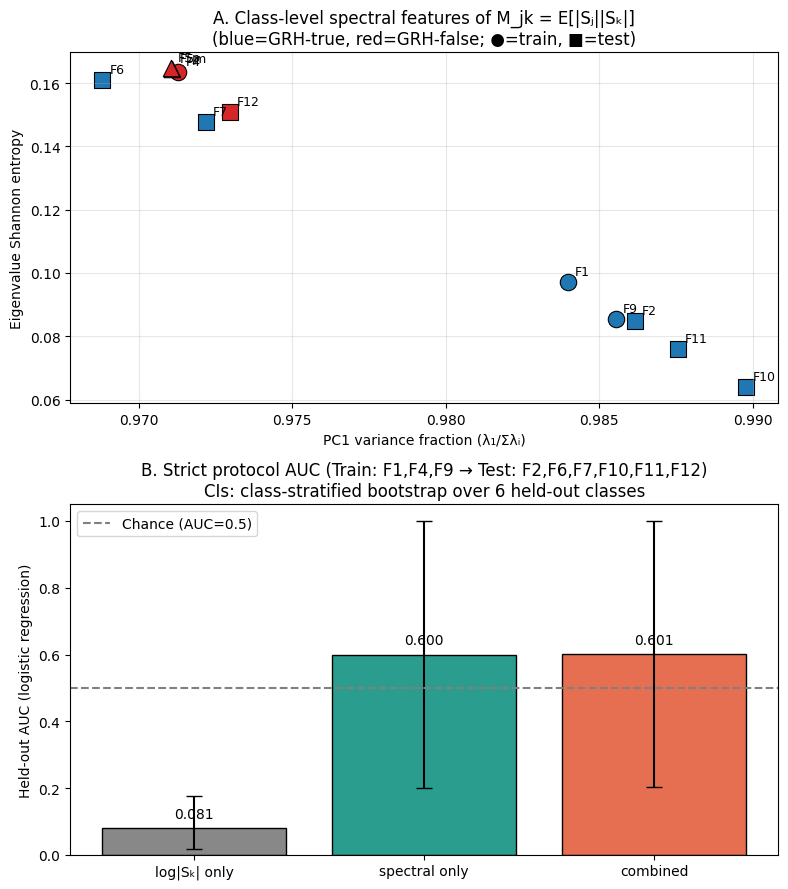

Saved figure.


In [12]:
# Final figure: 2 subfigures (A) per-class spectral features colored by GRH; (B) AUC bar with CI
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,1, figsize=(8,9))

# A: spectral feature scatter
ax = axes[0]
for cls in classes:
 sub = df[df['function']==cls].iloc[0]
 color = 'tab:blue' if sub['GRH'] else 'tab:red'
 marker = 'o' if cls in train_classes else ('s' if cls in test_classes else '^')
 ax.scatter(sub['pc1_variance_fraction'], sub['eigenvalue_entropy'],
 s=140, color=color, marker=marker, edgecolor='k', linewidth=0.8)
 ax.annotate(cls, (sub['pc1_variance_fraction'], sub['eigenvalue_entropy']),
 xytext=(5,5), textcoords='offset points', fontsize=9)
ax.set_xlabel('PC1 variance fraction (λ₁/Σλᵢ)')
ax.set_ylabel('Eigenvalue Shannon entropy')
ax.set_title('A. Class-level spectral features of M_jk = E[|Sⱼ||Sₖ|]\n(blue=GRH-true, red=GRH-false; ●=train, ■=test)')
ax.grid(alpha=0.3)

# B: AUC comparison
ax = axes[1]
names = ['logS_only','spectral_only','combined']
aucs = [final[n]['AUC'] for n in names]
los = [final[n]['CI95'][0] for n in names]
his = [final[n]['CI95'][1] for n in names]
err = [[a-l for a,l in zip(aucs,los)],[h-a for a,h in zip(aucs,his)]]
x = np.arange(len(names))
ax.bar(x, aucs, yerr=err, capsize=6, color=['#888','#2a9d8f','#e76f51'], edgecolor='k')
ax.axhline(0.5, color='gray', linestyle='--', label='Chance (AUC=0.5)')
ax.set_xticks(x); ax.set_xticklabels(['log|Sₖ| only','spectral only','combined'])
ax.set_ylabel('Held-out AUC (logistic regression)')
ax.set_title('B. Strict protocol AUC (Train: F1,F4,F9 → Test: F2,F6,F7,F10,F11,F12)\nCIs: class-stratified bootstrap over 6 held-out classes')
ax.set_ylim(0,1.05); ax.legend()
for xi, ai in zip(x, aucs):
 ax.text(xi, ai+0.03, f'{ai:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('spectral_vs_logS_strict_protocol.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved figure.')
